In [1]:
import pandas as pd

segment_speeds = pd.read_csv("segment_speeds.csv")

In [ ]:
# read in stop shedules
stop_times = pd.read_csv("nta_bus_mapping/data/gtfs_b/stop_times.txt", delimiter=",")

In [3]:
print(segment_speeds.columns)
print(segment_speeds.head())
# add weekday column
segment_speeds['day_type'] = segment_speeds[
'Day of Week'
].apply(lambda x: 'Weekday' if x in ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"] else 'Weekend')
segment_speeds['stop_pair'] = segment_speeds['Timepoint Stop Name'] + " - " + segment_speeds['Next Timepoint Stop Name']

Index(['Year', 'Month', 'Timestamp', 'Day of Week', 'Hour of Day', 'Route ID',
       'Direction', 'Borough', 'Route Type', 'Stop Order', 'Timepoint Stop ID',
       'Timepoint Stop Name', 'Timepoint Stop Latitude',
       'Timepoint Stop Longitude', 'Next Timepoint Stop ID',
       'Next Timepoint Stop Name', 'Next Timepoint Stop Latitude',
       'Next Timepoint Stop Longitude', 'Road Distance', 'Average Travel Time',
       'Average Road Speed', 'Bus Trip Count', 'Timepoint Stop Georeference',
       'Next Timepoint Stop Georeference'],
      dtype='object')
   Year  Month                Timestamp Day of Week  Hour of Day Route ID  \
0  2025      3  2025 Mar 01 05:00:00 PM    Thursday           17       B3   
1  2025      3  2025 Mar 01 10:00:00 AM    Thursday           10      B84   
2  2025      3  2025 Mar 01 06:00:00 PM    Thursday           18      B84   
3  2025      3  2025 Mar 01 10:00:00 AM    Thursday           10     BXM1   
4  2025      3  2025 Mar 01 12:00:00 PM    Thur

In [7]:
# Group by month, day_type, hour, stop name, print n and average travel time to next timepoint stop
grouped = bus_route_speeds.groupby(["Month", "day_type", "Hour of Day", "Direction", "stop_pair"]).agg(
    n=("Average Travel Time", "count"),
    avg_travel_time=("Average Travel Time", "mean")
).reset_index()
grouped.to_csv("/tmp/grouped_speeds.csv", index=False)

In [ ]:
import re

def weighed_lateness_by_borough(path):

    # read in stop shedules
    stop_times = pd.read_csv(f"{path}/stop_times.txt", delimiter=",")

    # Filter to just timepoints
    stop_times = stop_times[stop_times['timepoint'] == 1]

    # Calculate the average difference in departure time between each pair of stops on a trip during a given hour
    stop_times['hour'] = stop_times['departure_time'].astype(str).str.split(':').str[0].astype(int)

    # extract route, trip number from trip_id
    stop_times[['route', 'trip_number']] = stop_times['trip_id'].str.split('_').apply(
        lambda x: pd.Series([x[2], x[3]] if len(x) == 4 else ["NA", "NA"])
    )

    # This is where it get real claudy - finds the average travel time between timepoints as per the schedule


    # Filter to timepoint stops only
    tp = stop_times[stop_times['timepoint'] == 1].sort_values(['trip_id', 'stop_sequence']).copy()

    # Parse departure_time to total seconds
    tp['dep_seconds'] = tp['departure_time'].str.split(':').apply(lambda x: int(x[0])*3600 + int(x[1])*60 + int(x[2]))

    # Use the departure hour of each stop (matches segment_speeds' per-segment Hour of Day)
    tp['hour'] = tp['dep_seconds'] // 3600

    # Join stop names from stops.txt
    stops = pd.read_csv(f"{path}/stops.txt")
    tp = tp.merge(stops[['stop_id', 'stop_name']], on='stop_id', how='left')

    # Expand combined routes like B6769 -> B67 + B69 (pattern: 1 letter + 4 digits)
    mask = tp['route'].str.match(r'^[A-Z]\d{4}$', na=False)
    combined = tp[mask].copy()
    if len(combined) > 0:
        print(f"Expanding {combined['route'].nunique()} combined routes: {combined['route'].unique()}")
        route1 = combined.copy()
        route1['route'] = combined['route'].str[0] + combined['route'].str[1:3]
        route2 = combined.copy()
        route2['route'] = combined['route'].str[0] + combined['route'].str[3:5]
        tp = pd.concat([tp[~mask], route1, route2], ignore_index=True)

    # Re-sort after concat to ensure shift works correctly within each trip
    tp = tp.sort_values(['trip_id', 'route', 'stop_sequence'])

    # Compute time to next timepoint within each trip
    tp['next_stop_id'] = tp.groupby(['trip_id', 'route'])['stop_id'].shift(-1)
    tp['next_stop_name'] = tp.groupby(['trip_id', 'route'])['stop_name'].shift(-1)
    tp['next_dep_seconds'] = tp.groupby(['trip_id', 'route'])['dep_seconds'].shift(-1)
    tp['travel_time_min'] = (tp['next_dep_seconds'] - tp['dep_seconds']) / 60

    # Drop last stop of each trip (no "next")
    tp = tp.dropna(subset=['next_stop_id'])
    tp['next_stop_id'] = tp['next_stop_id'].astype(int)

    # Build stop_pair using IDs (unambiguous) and names (for display)
    tp['stop_pair_id'] = tp['stop_id'].astype(str) + '_' + tp['next_stop_id'].astype(str)
    tp['stop_pair'] = tp['stop_name'] + " - " + tp['next_stop_name']

    # Average scheduled travel time by route, hour, stop_pair_id
    scheduled = tp.groupby(['route', 'hour', 'stop_pair_id', 'stop_pair']).agg(
        scheduled_avg_min=('travel_time_min', 'mean'),
        n_trips=('travel_time_min', 'count')
    ).reset_index()

    print(f"Scheduled rows: {len(scheduled)}")
    scheduled.head()

    # Combined segment speeds with scheduled times to calculate average unexpected length between stops during each hour


    # Build stop_pair_id in segment_speeds using numeric Stop IDs
    segment_speeds['stop_pair_id'] = segment_speeds['Timepoint Stop ID'].astype(str) + '_' + segment_speeds['Next Timepoint Stop ID'].astype(str)

    # Merge on route + hour + stop_pair_id
    merged = segment_speeds.merge(
        scheduled,
        left_on=['Route ID', 'Hour of Day', 'stop_pair_id'],
        right_on=['route', 'hour', 'stop_pair_id'],
        how='inner'
    )
    print(f"Merged rows: {len(merged)}")

    # Calculate lateness (use stop_pair_y from scheduled, which has proper names)
    merged = merged[['Year', 'Month', 'day_type', 'hour', 'stop_pair_y', 'stop_pair_id', 'Route ID', 'Average Travel Time', 'scheduled_avg_min', 'n_trips']]
    merged = merged.rename(columns={'stop_pair_y': 'stop_pair'})
    merged['lateness'] = merged['Average Travel Time'] - merged['scheduled_avg_min']
    merged.head()

    merged['is_late'] = merged['lateness'] > 0
    merged.to_csv("/tmp/merged_with_lateness.csv", index=False)
    # merged['is_peak'] = (merged['hour'] >= 6) & (merged['hour'] < 9) | (merged['hour'] >= 15) & (merged['hour'] < 19)
    merged['period'] = merged['hour'].apply(lambda x: 'Peak' if (6 <= x < 9) or (15 <= x < 19) else 'Off-Peak')
    late_percentage = merged.groupby(['Route ID', 'period']).agg(
        {'is_late': 'mean', 'n_trips': 'sum'}
    )
    print(late_percentage.sort_values(by='is_late', ascending=False))

    merged['weighted_lateness'] = merged['lateness'] * merged['n_trips']
    weighted_lateness = (
        merged.groupby("Route ID")
        .agg(wl=('weighted_lateness', 'sum'), nt=('n_trips', 'sum'))
    )
    weighted_lateness['weighted_avg_lateness'] = weighted_lateness['wl'] / weighted_lateness['nt']
    weighted_lateness = weighted_lateness[['weighted_avg_lateness']].reset_index()
    return weighted_lateness


queens = weighed_lateness_by_borough("nta_bus_mapping/data/gtfs_q")

Scheduled rows: 14384
Merged rows: 457909
                    is_late  n_trips
Route ID period                     
Q88      Off-Peak  0.796589     9698
Q61      Off-Peak  0.791946     6862
         Peak      0.785843     4740
Q38      Off-Peak  0.764454    14618
         Peak      0.763992    17150
...                     ...      ...
Q45      Peak      0.306723    14076
QM68     Peak      0.265152     6084
         Off-Peak  0.187500     1812
Q90      Peak      0.046688    19765
         Off-Peak  0.030965    30353

[78 rows x 2 columns]


In [ ]:
brooklyn = weighed_lateness_by_borough("nta_bus_mapping/data/gtfs_b")
bronx = weighed_lateness_by_borough("nta_bus_mapping/data/gtfs_bx")
manhattan = weighed_lateness_by_borough("nta_bus_mapping/data/gtfs_m")
si = weighed_lateness_by_borough("nta_bus_mapping/data/gtfs_si")

NotADirectoryError: [Errno 20] Not a directory: 'nta_bus_mapping/data/gtfs_b/stop_times.txt/stop_times.txt'

In [15]:
brooklyn.to_csv("weighted_lateness_brooklyn.csv", index=False)
queens.to_csv("weighted_lateness_queens.csv", index=False)
bronx.to_csv("weighted_lateness_bronx.csv", index=False)
manhattan.to_csv("weighted_lateness_manhattan.csv", index=False)
si.to_csv("weighted_lateness_si.csv", index=False)

In [ ]:
# Combined segment speeds with scheduled times to calculate average unexpected length between stops during each hour


# Build stop_pair_id in segment_speeds using numeric Stop IDs
segment_speeds['stop_pair_id'] = segment_speeds['Timepoint Stop ID'].astype(str) + '_' + segment_speeds['Next Timepoint Stop ID'].astype(str)

# Merge on route + hour + stop_pair_id
merged = segment_speeds.merge(
    scheduled,
    left_on=['Route ID', 'Hour of Day', 'stop_pair_id'],
    right_on=['route', 'hour', 'stop_pair_id'],
    how='inner'
)
print(f"Merged rows: {len(merged)}")

# Calculate lateness (use stop_pair_y from scheduled, which has proper names)
merged = merged[['Year', 'Month', 'day_type', 'hour', 'stop_pair_y', 'stop_pair_id', 'Route ID', 'Average Travel Time', 'scheduled_avg_min', 'n_trips']]
merged = merged.rename(columns={'stop_pair_y': 'stop_pair'})
merged['lateness'] = merged['Average Travel Time'] - merged['scheduled_avg_min']
merged.head()



Merged rows: 1400050


,Year,Month,day_type,hour,stop_pair,stop_pair_id,Route ID,Average Travel Time,scheduled_avg_min,n_trips,lateness
0,2025,3,Weekday,17,AVENUE U/NOSTRAND AV - AVENUE U/FLATBUSH AV,300208_300220,B3,13.070508,10.333333,27,2.737175
1,2025,3,Weekday,10,LIVONIA AV/ASHFORD ST - COZINE AV/ASHFORD ST,306921_300590,B84,4.416678,4.333333,6,0.083345
2,2025,3,Weekday,18,LIVONIA AV/ASHFORD ST - COZINE AV/ASHFORD ST,306921_300590,B84,6.199998,4.714286,7,1.485712
3,2025,3,Weekday,7,AVENUE U/NOSTRAND AV - AVENUE U/FLATBUSH AV,300208_300220,B3,8.406450,9.333333,21,-0.926883
4,2025,3,Weekday,8,LIVONIA AV/ASHFORD ST - COZINE AV/ASHFORD ST,306921_300590,B6,6.086586,5.282051,39,0.804535


In [13]:
merged.sort_values('lateness', ascending=False).to_csv("/tmp/merged_speeds.csv", index=False)

In [ ]:
merged['is_late'] = merged['lateness'] > 0
merged.to_csv("/tmp/merged_with_lateness.csv", index=False)
# merged['is_peak'] = (merged['hour'] >= 6) & (merged['hour'] < 9) | (merged['hour'] >= 15) & (merged['hour'] < 19)
merged['period'] = merged['hour'].apply(lambda x: 'Peak' if (6 <= x < 9) or (15 <= x < 19) else 'Off-Peak')
late_percentage = merged.groupby(['Route ID', 'period']).agg(
    {'is_late': 'mean', 'n_trips': 'sum'}
)
print(late_percentage.sort_values(by='is_late', ascending=False))

weighted_lateness = (
    merged.groupby(["Route ID"])
      .apply(lambda g: (g["lateness"] * g["n_trips"]).sum() / g["n_trips"].sum())
      .reset_index(name="weighted_avg_lateness")
)
print(weighted_lateness.sort_values(by='weighted_avg_lateness', ascending=False))
weighted_lateness.to_csv("/tmp/weighted_lateness_queens.csv", index=False)

                    is_late  n_trips
Route ID period                     
B32      Peak      0.886885    12498
         Off-Peak  0.848651    12216
B37      Off-Peak  0.818559    70925
Q29      Peak      0.786925    42510
         Off-Peak  0.751647    52477
...                     ...      ...
Q54      Peak      0.365966   208474
B69      Peak      0.349761   195879
Q55      Peak      0.309661    38621
         Off-Peak  0.263942    59010
B39      Off-Peak  0.222222     4606

[130 rows x 2 columns]
   Route ID  weighted_avg_lateness
63      X37               1.790642
15      B32               1.653259
55      Q39               1.520685
54      Q29               1.115978
18      B37               1.003327
..      ...                    ...
43      B69              -0.290850
46      B74              -0.323288
23      B42              -0.353862
60      Q67              -0.405200
57      Q55              -0.821749

[65 rows x 2 columns]


/tmp/ipykernel_6562/3711864550.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g["lateness"] * g["n_trips"]).sum() / g["n_trips"].sum())


     route_id  weighted_avg_lateness  wait_assessment
4592      Q29               0.980431         0.812382
4591      Q29               0.980431         0.793188
4590      Q29               0.963796         0.841746
4589      Q29               0.963796         0.811851
8132      X37               0.934659         0.657421
...       ...                    ...              ...
8195      X68                    NaN         0.752542
8196      X68                    NaN         0.731183
8197      X68                    NaN         0.765468
8198      X68                    NaN         0.765244
8199      X68                    NaN         0.763492

[8200 rows x 3 columns]
R^2: 0.0169
Spearman r: -0.1212, p-value: 0.0000


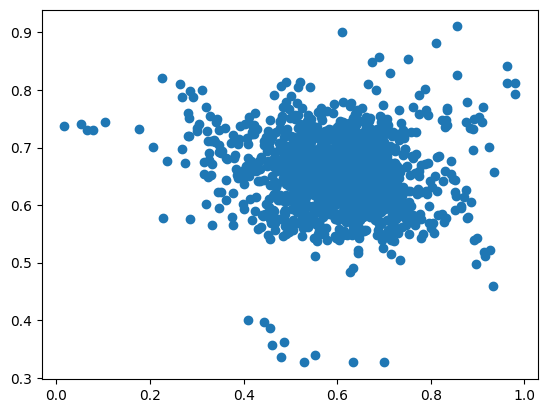

: 

In [ ]:
import matplotlib.pyplot as plt

bus_waittimes = pd.read_csv("MTA_Bus_Wait_Assessment__Beginning_2015.csv")
# join with late_percentage on route ID to see if routes with more late trips also have longer wait times
# filter to just 2025 and 2026
# weekday peak is 6am to 9am and 3pm to 7pm
bus_waittimes['year'] = bus_waittimes['month'].str.extract(r'(\d{4})')
bus_waittimes = bus_waittimes[(bus_waittimes['year'] == '2025') | (bus_waittimes['year'] == '2026')]
bus_waittimes['month_num'] = bus_waittimes['month'].str[5:7].astype(int)
# group bus waittimes by route_id and period, take average wait_assessment
bus_waittimes = bus_waittimes.groupby(['route_id', 'period', 'month_num']).agg(
    wait_assessment=('wait_assessment', 'mean')
).reset_index()

bus_waittimes = bus_waittimes.merge(
    weighted_lateness.rename(columns={'Route ID': 'route_id', 'Month': 'month_num'}),
    on=['route_id', 'period', 'month_num'],
    how='left'
)
print(bus_waittimes[['route_id', 'weighted_avg_lateness', 'wait_assessment']].sort_values('weighted_avg_lateness', ascending=False))
# plot
plt.scatter(bus_waittimes['weighted_avg_lateness'], bus_waittimes['wait_assessment'])

# calculate r^2 of late_percentage vs wait_assessment
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
model = LinearRegression()
bus_waittimes = bus_waittimes[bus_waittimes['route_id'].str.startswith('B')]
valid = bus_waittimes.dropna(subset=['weighted_avg_lateness', 'wait_assessment'])
X = valid['weighted_avg_lateness'].values.reshape(-1, 1)
y = valid['wait_assessment'].values
model.fit(X, y)
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
print(f"R^2: {r2:.4f}")

from scipy.stats import spearmanr

corr, pvalue = spearmanr(valid['weighted_avg_lateness'], valid['wait_assessment'])
print(f"Spearman r: {corr:.4f}, p-value: {pvalue:.4f}")

In [51]:
print(bus_waittimes['month_num'].unique())
print(weighted_lateness['Month'].unique())

[20]
[ 1  2  3  4  5  6  7  8  9 10 11 12]


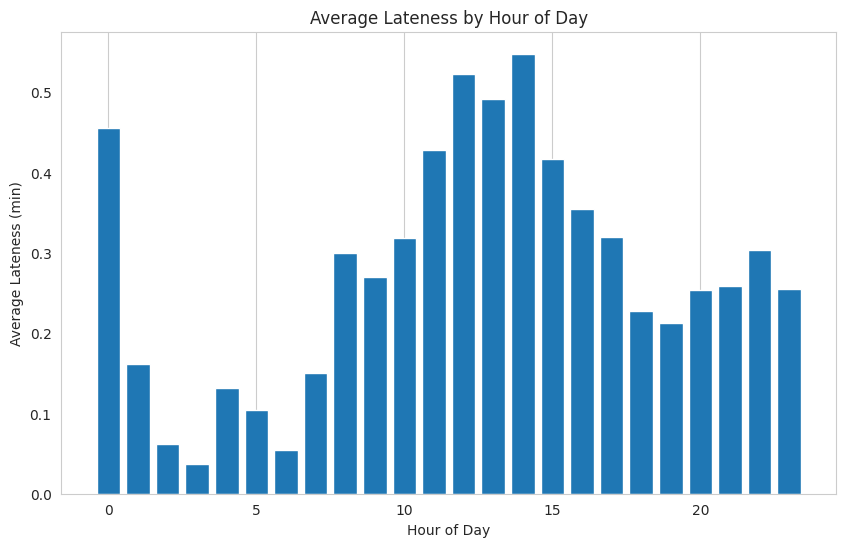

In [ ]:

# find percent of buses that were >3 minutes late and plot


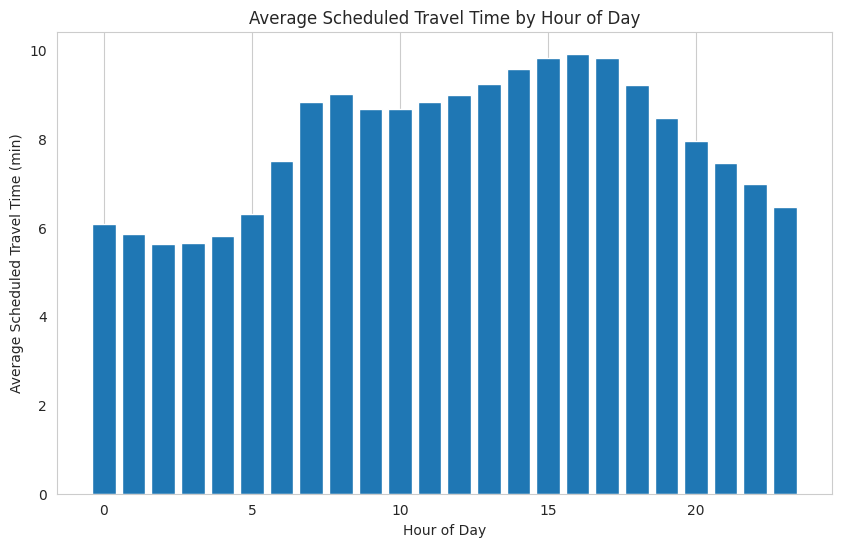

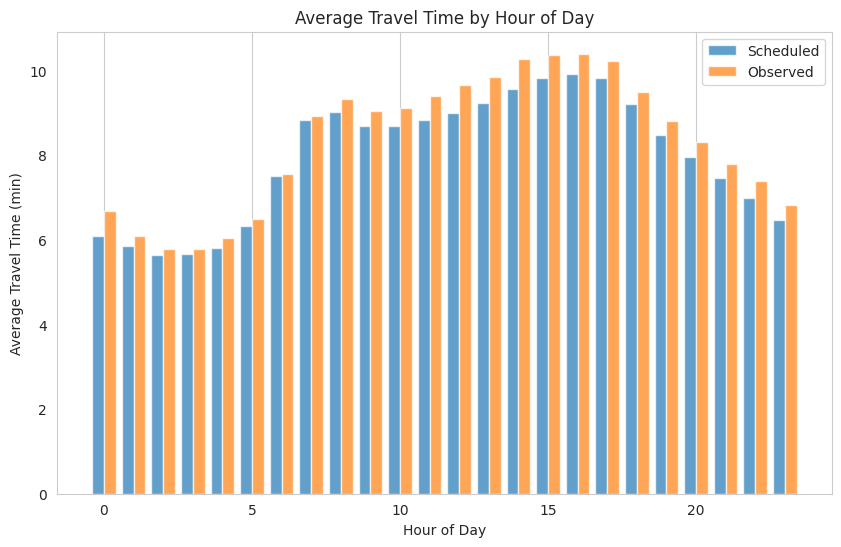

In [98]:
# plot average scheduled time by hour of day
avg_scheduled_by_hour = merged.groupby('hour')['scheduled_avg_min'].mean()
plt.figure(figsize=(10, 6))
plt.bar(avg_scheduled_by_hour.index, avg_scheduled_by_hour.values)
plt.title('Average Scheduled Travel Time by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Scheduled Travel Time (min)')
plt.grid(axis='y')
# plt.show()

# plot average observed times on top of scheduled times by hour of day
avg_observed_by_hour = merged.groupby('hour')['Average Travel Time'].mean()
plt.figure(figsize=(10, 6))
plt.bar(avg_scheduled_by_hour.index - 0.2, avg_scheduled_by_hour.values, width=0.4, label='Scheduled', alpha=0.7)
plt.bar(avg_observed_by_hour.index + 0.2, avg_observed_by_hour.values, width=0.4, label='Observed', alpha=0.7)
plt.title('Average Travel Time by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Travel Time (min)')
plt.grid(axis='y')
plt.legend()
plt.show()

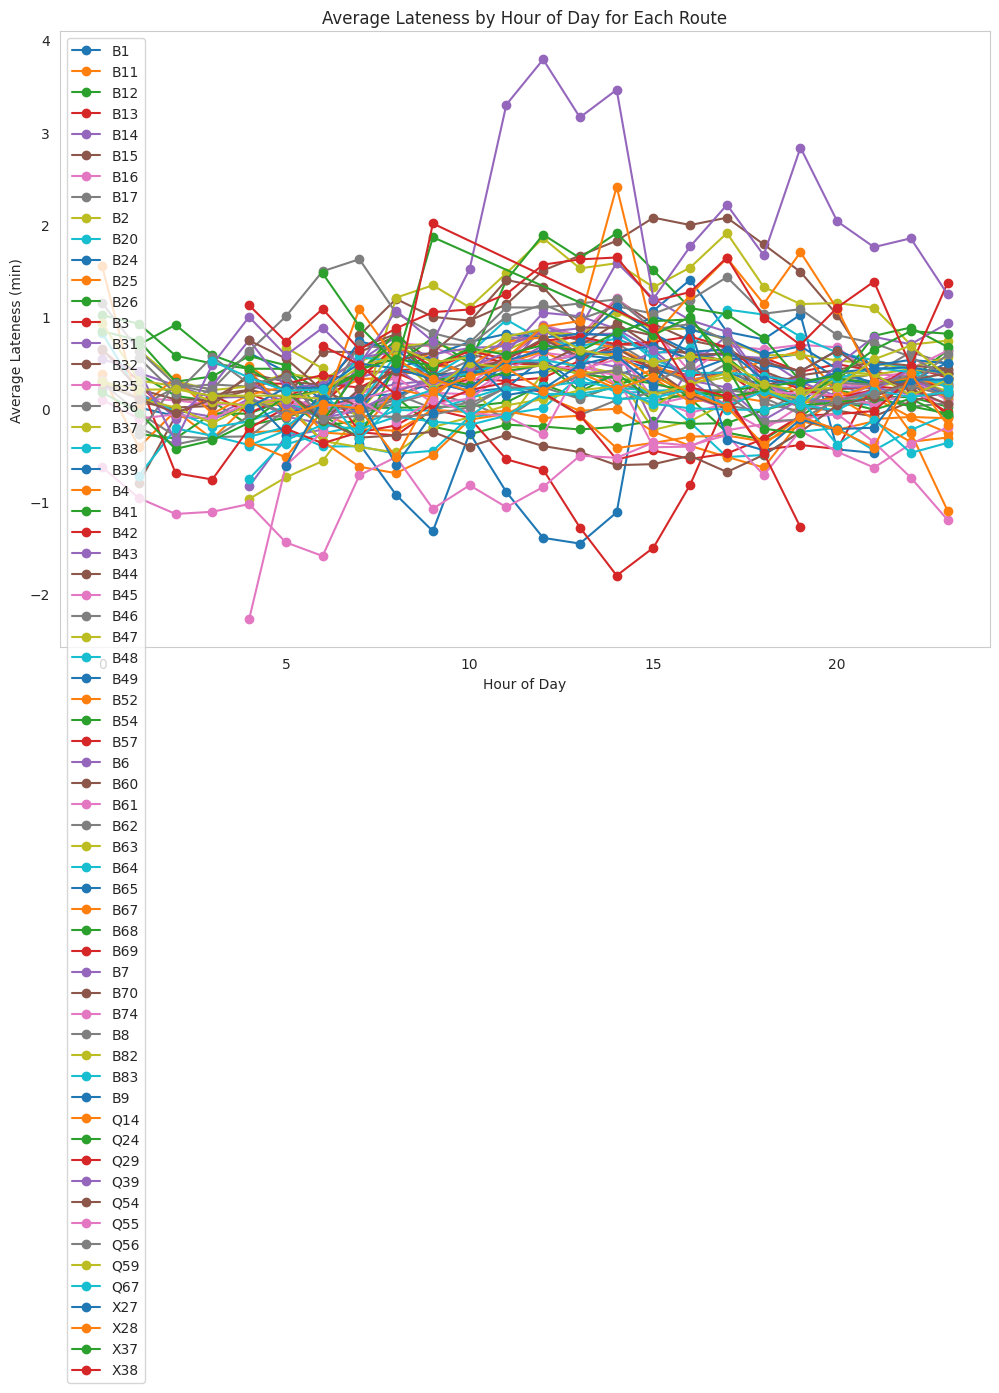

In [76]:
# plot each bus route's average lateness at each time throughout the day
avg_by_route_hour = merged.groupby(['Route ID', 'hour'])['lateness'].median().reset_index()
plt.figure(figsize=(12, 8))
for route in avg_by_route_hour['Route ID'].unique():
    route_data = avg_by_route_hour[avg_by_route_hour['Route ID'] == route]
    plt.plot(route_data['hour'], route_data['lateness'], marker='o', label=route)
plt.title('Average Lateness by Hour of Day for Each Route')
plt.xlabel('Hour of Day')
plt.ylabel('Average Lateness (min)')
plt.legend()
plt.grid()
plt.show()